# Day 2 (R parallel): the continuous pipeline in `economiccomplexity`

This is the R companion to the Day 2 Python notebook. Today the whole day runs on the continuous presence matrix M-hat = RCA / (1 + RCA), and the package does the heavy lifting. We build M-hat, hand it to `economiccomplexity` for ECI, PCI, proximity, and density, and read the same diversification shortlist the Python notebook produces. Each package call is a line or two of matrix algebra open underneath, which we note as we go. The binary Mcp from Day 1 stays only for the handshake (diversity 129) and to mark the country's current basket on the product space.

`COUNTRY`, `COMPARATORS`, and `YEAR` at the top drive every result. Edit them to point the notebook at your own country.

## 0. Setup

Same packet as Day 1, plus the two product-space layout files. The notebook installs its two missing packages and downloads the data on first run, so it works on Colab's R runtime as well as locally.

In [1]:
# Packages first. Colab's R runtime compiles CRAN packages from source, which
# can take tens of minutes for arrow and igraph. Posit's public package manager
# serves prebuilt Linux binaries of the same CRAN packages, so on Linux we
# install from there and the same installs finish in about a minute. Mac and
# Windows already get binaries from the regular CRAN mirror, so they keep it.
if (Sys.info()[["sysname"]] == "Linux") {
  # igraph's compiled code links against the GLPK system library, which
  # Colab's image does not ship. No R install can supply a system library,
  # so we add it with apt (a few seconds). This must run even when the R
  # packages are already installed, or loading igraph fails with
  # "libglpk.so.40: cannot open shared object file".
  if (!any(grepl("libglpk", system("ldconfig -p", intern = TRUE)))) {
    cat("Installing the GLPK system library that igraph needs ...\n")
    system("apt-get update -qq && apt-get install -y -qq libglpk40")
  }
}
needed <- setdiff(
  c("economiccomplexity", "arrow", "dplyr", "readr", "ggplot2"),
  rownames(installed.packages())
)
if (length(needed) > 0) {
  if (Sys.info()[["sysname"]] == "Linux") {
    codename <- system(". /etc/os-release && echo $VERSION_CODENAME", intern = TRUE)
    options(
      repos = c(CRAN = paste0(
        "https://packagemanager.posit.co/cran/__linux__/", codename, "/latest"
      )),
      HTTPUserAgent = sprintf(
        "R/%s R (%s)", getRversion(),
        paste(getRversion(), R.version$platform, R.version$arch, R.version$os)
      )
    )
  }
  install.packages(needed)
}
suppressMessages({
  library(arrow) # read the packet's .parquet files
  library(dplyr) # filter, select, group, summarise
  library(readr) # read the reference tables
  library(ggplot2) # the product-space figure
  library(economiccomplexity) # balassa_index(), complexity_measures(), complexity_outlook()
})

# --- The ONE place you edit to make this notebook about your own country. ------
# Codes are ISO 3166-1 alpha-2 (two letters). MA = Morocco, EG = Egypt,
# TN = Tunisia, KR = Republic of Korea. See reference/units.csv.
COUNTRY <- "MA" # the focus country (Morocco)
COMPARATORS <- c("EG", "TN", "KR") # Egypt, Tunisia (MENA) + Korea (frontier)
YEAR <- 2023 # latest year in the packet
# -------------------------------------------------------------------------------

# Resolve the data packet: the course repository's copy when it exists, and
# otherwise (Colab included) a one-time download of the two archives this
# notebook needs from the course data release, the same source the Python
# notebooks use.
PACKET <- normalizePath(
  file.path("..", "..", "data", "processed", "morocco_data_packet"),
  mustWork = FALSE
)
DATA_RELEASE <- "https://github.com/shreyasgm/ecu-complexity-labs/releases/download/data-v1"
if (!dir.exists(PACKET)) {
  PACKET <- normalizePath("morocco_data_packet", mustWork = FALSE)
  options(timeout = max(600, getOption("timeout"))) # exports.zip is about 45 MB
  for (folder in c("exports", "reference")) {
    if (!dir.exists(file.path(PACKET, folder))) {
      cat("Downloading", paste0(folder, ".zip"), "from the course data release ...\n")
      zf <- tempfile(fileext = ".zip")
      download.file(paste0(DATA_RELEASE, "/", folder, ".zip"), zf, mode = "wb", quiet = TRUE)
      unzip(zf, exdir = PACKET)
      unlink(zf)
    }
  }
}

# Fail loud on anything missing, naming the exact file.
required <- c(
  file.path(PACKET, "exports", "outputs.parquet"),
  file.path(PACKET, "exports", "densities.parquet"),
  file.path(PACKET, "reference", "fields.csv"),
  file.path(PACKET, "reference", "units.csv"),
  file.path(PACKET, "reference", "umap_layout_hs92.csv"),
  file.path(PACKET, "reference", "top_edges_hs92.csv")
)
missing <- required[!file.exists(required)]
if (length(missing) > 0) {
  stop(
    "Required packet file(s) not found:\n  ", paste(missing, collapse = "\n  "), "\n",
    "Delete the morocco_data_packet folder and re-run this cell to retry the ",
    "download. The product-space layout files were added to reference.zip on ",
    "7 July, so a packet fetched before then needs the re-download."
  )
}
cat("Packet found:", PACKET, "\n")
cat("Focus country:", COUNTRY, "| comparators:", paste(COMPARATORS, collapse = ", "), "| year:", YEAR, "\n")

Packet found: /Users/shg309/Library/CloudStorage/Dropbox-Personal/Education/hks_cid_growth_lab/misc/morocco_summer_school/data/processed/morocco_data_packet 


Focus country: MA | comparators: EG, TN, KR | year: 2023 


In [2]:
# outputs.parquet and fields.csv are Day 1's tables; the two layout files position
# the product space. We keep the reference column names with spaces intact so the
# codes line up with the packet.
exports <- read_parquet(file.path(PACKET, "exports", "outputs.parquet"))
fields <- read.csv(
  file.path(PACKET, "reference", "fields.csv"),
  check.names = FALSE, stringsAsFactors = FALSE
)
prod_name <- setNames(fields$`Field Name`, fields$`Field ID`)

year_long <- exports %>%
  filter(Period == YEAR) %>%
  select(Unit, `Field ID`, Outputs)
cat("countries:", n_distinct(year_long$Unit), "| products:", n_distinct(year_long$`Field ID`), "\n")

countries: 191 | products: 862 


## 1. Rebuild Day 1's binary Mcp

The binary Mcp still anchors the day. `balassa_index(discrete = TRUE, cutoff = 1)` gives it in one call, diversity is the row sum, and Morocco's count must match yesterday's 129.

In [3]:
mcp <- balassa_index(
  year_long,
  discrete = TRUE, cutoff = 1,
  country = "Unit", product = "Field ID", value = "Outputs"
)
diversity <- rowSums(mcp)
cat(COUNTRY, "diversity:", diversity[COUNTRY], "| matrix:", nrow(mcp), "x", ncol(mcp), "\n")

# Self-check: the Day 1 handshake. Same data and method, so the same 129.
if (diversity[COUNTRY] != 129) {
  stop("Morocco's diversity is ", diversity[COUNTRY], " but Day 1 printed 129.")
}
cat("OK: yesterday's Mcp reproduced (Morocco diversity = 129).\n")

MA diversity: 129 | matrix: 191 x 862 


OK: yesterday's Mcp reproduced (Morocco diversity = 129).


## 2. Complexity without the threshold

Day 1 ended with the RCA cutoff of 1 looking arbitrary. The continuous fix transforms RCA into a bounded weight, M-hat = RCA / (1 + RCA), so an RCA of 1 becomes 0.5. We hand M-hat straight to `complexity_measures()`, which runs the same eigenvalue routine on the weights, standardizes the result, and sign-corrects it to rise with diversity. Then we compare the country ranking to the binary one.

In [4]:
# Continuous RCA from the same call with discrete = FALSE, then the transformation.
rca <- as.matrix(balassa_index(
  year_long,
  discrete = FALSE,
  country = "Unit", product = "Field ID", value = "Outputs"
))
m_hat <- rca / (1 + rca)
cat("m_hat range:", round(min(m_hat), 3), "to", round(max(m_hat), 4), "(RCA = 1 maps to 0.5)\n")

m_hat range: 0 to 0.9998 (RCA = 1 maps to 0.5)


In [5]:
# ECI and PCI two ways: binary Mcp (yesterday's index) and continuous M-hat
# (today's). Everything downstream uses the continuous PCI.
eci_bin <- complexity_measures(mcp, method = "eigenvalues")$complexity_index_country
cm_con <- complexity_measures(m_hat, method = "eigenvalues")
eci_con <- cm_con$complexity_index_country
pci_con <- cm_con$complexity_index_product

common_c <- intersect(names(eci_bin), names(eci_con))
rho_bc <- cor(eci_bin[common_c], eci_con[common_c], method = "spearman")
cat(
  COUNTRY, "binary ECI:", round(eci_bin[COUNTRY], 3), "(rank", rank(-eci_bin)[COUNTRY],
  ") | continuous ECI:", round(eci_con[COUNTRY], 3), "(rank", rank(-eci_con)[COUNTRY], ")\n"
)
cat("Comparator rank shift (binary -> continuous):\n")
for (code in COMPARATORS) {
  if (code %in% common_c) {
    cat("  ", code, ":", rank(-eci_bin)[code], "->", rank(-eci_con)[code], "\n")
  }
}
cat("Spearman(binary ECI, continuous ECI) =", round(rho_bc, 3), "over", length(common_c), "countries\n")

# Self-check: the two rankings agree strongly without being identical. Perfect
# agreement would mean the threshold never mattered; a weak value would mean the
# index is fragile. The Python notebook's 0.965 lives in between.
if (!(rho_bc > 0.85 && rho_bc < 0.9999)) {
  stop("binary and continuous ECI should rank countries almost alike (got ", round(rho_bc, 3), ").")
}
cat("OK: dropping the threshold barely moves the ranking (Spearman", round(rho_bc, 3), ").\n")

applying sign correction to product index...



applying sign correction to country index...



MA binary ECI: -0.468 (rank 123 ) | continuous ECI: -0.062 (rank 111 )


Comparator rank shift (binary -> continuous):


   EG : 97 -> 97 
   TN : 72 -> 62 
   KR : 3 -> 2 


Spearman(binary ECI, continuous ECI) = 0.965 over 191 countries


OK: dropping the threshold barely moves the ranking (Spearman 0.965 ).


## 3. Proximity

Proximity is the smaller of the two conditional co-export probabilities, and the package computes it for all 862 products on the continuous M-hat in one call. Under the hood it is three lines of matrix algebra: the weighted co-occurrence of every product pair (t(m_hat) %*% m_hat), divided by each product's weighted ubiquity to get the two conditionals, then the elementwise minimum. The Python notebook keeps that hand-roll as a stretch. We zero the self-proximity diagonal so a product is not counted as related to itself, which matters for the density denominator below.

In [6]:
prox <- proximity(m_hat, compute = "product")
diag(prox$proximity_product) <- 0 # drop self-proximity; keep this object for density()
phi <- as.matrix(prox$proximity_product)

pair_value <- phi["P - 6106", "P - 6104"]
upper <- phi[upper.tri(phi)]
cat(
  "phi(Women's Knit Shirts, Women's Knit Suits) =", round(pair_value, 3),
  "| higher than", sprintf("%.1f%%", 100 * mean(upper < pair_value)), "of all pairs\n"
)

# Self-check: symmetric, bounded, zero on the diagonal, and the flagship pair on
# top. The continuous value is 0.538, not the lecture's 0.967, because that came
# from binary Mcp on 2010 data and ours is continuous on 2023 data. The pair still
# beats essentially every other pair, so the method is stable even where the
# number moves.
if (!isTRUE(all.equal(phi, t(phi)))) stop("phi must be symmetric.")
if (min(phi) < 0 || max(phi) > 1) stop("phi is a probability-like weight and must lie in [0, 1].")
if (abs(pair_value - 0.538) > 0.01) {
  stop("phi(P - 6106, P - 6104) should reproduce the Python's continuous 0.538, got ", round(pair_value, 3), ".")
}
if (!(mean(upper < pair_value) > 0.99)) stop("the shirts/suits pair should land near the top of all pairs.")
cat("OK: proximity is symmetric, bounded, and ranks the flagship pair on top (0.538).\n")

phi(Women's Knit Shirts, Women's Knit Suits) = 0.538 | higher than 100.0% of all pairs


OK: proximity is symmetric, bounded, and ranks the flagship pair on top (0.538).


In [7]:
# Why the min and not the max? The package returned the symmetric min. The two
# directions that go into it are one matrix product away, so we open them up for
# the most lopsided pair: Oxometallic Salts (two exporters, yesterday's top-PCI
# product) against Non-Aqueous Paints (42).
co <- t(m_hat) %*% m_hat
conditional <- sweep(co, 1, colSums(m_hat), "/")
p_rare <- "P - 2841" # Oxometallic Salts
p_common <- "P - 3208" # Non-Aqueous Paints
cat(prod_name[p_rare], "->", prod_name[p_common], ":", round(conditional[p_rare, p_common], 2), "\n")
cat(prod_name[p_common], "->", prod_name[p_rare], ":", round(conditional[p_common, p_rare], 2), "\n")
cat("symmetric phi (the min):", round(phi[p_rare, p_common], 2), "\n")

Oxometallic Salts -> Non-Aqueous Paints : 0.43 


Non-Aqueous Paints -> Oxometallic Salts : 0.05 


symmetric phi (the min): 0.05 


Nearly everyone who makes Oxometallic Salts also makes paints, so one direction looks strong. Almost no paint maker makes Oxometallic Salts, so the other is near zero. The max would call the pair related on the evidence of two countries; the min keeps only what holds both ways. This is the wine and ostrich eggs problem from the lecture, in our own data.

In [8]:
# Cross-check on Day 1's binary toy table, small enough to count by hand. Only
# Country B exports both Wheat and Textiles, so phi = 1 / max(1, 2) = 0.5; only
# Country A exports both Motorcycles and Cell phones, so that pair is 1.0. The
# package's proximity() must land on the same numbers you count on your fingers.
toy <- data.frame(
  country = rep(c("Country A", "Country B", "Country C"), each = 4),
  product = rep(c("Wheat", "Textiles", "Motorcycles", "Cell phones"), times = 3),
  value = c(10, 40, 100, 300, 150, 100, 10, 0, 20, 200, 1, 0),
  stringsAsFactors = FALSE
)
toy <- toy[toy$value > 0, ] # a country with no export of a product has no row
toy_mcp <- balassa_index(toy, discrete = TRUE, cutoff = 1)
toy_phi <- as.matrix(proximity(toy_mcp, compute = "product")$proximity_product)
diag(toy_phi) <- 0
cat(
  "toy phi(Wheat, Textiles) =", toy_phi["Wheat", "Textiles"],
  "| phi(Motorcycles, Cell phones) =", toy_phi["Motorcycles", "Cell phones"], "\n"
)

# Self-check: exact by construction, so the package must agree with the hand count.
if (abs(toy_phi["Wheat", "Textiles"] - 0.5) > 1e-9 ||
  abs(toy_phi["Motorcycles", "Cell phones"] - 1.0) > 1e-9) {
  stop("the package's proximity() on the toy must be 0.5 and 1.0, the min-of-conditionals counted by hand.")
}
cat("OK: hand count and package proximity agree on the toy (0.5, 1.0).\n")

toy phi(Wheat, Textiles) = 0.5 | phi(Motorcycles, Cell phones) = 1 


OK: hand count and package proximity agree on the toy (0.5, 1.0).


## 4. The product space

We draw the Growth Lab's published layout and highlight the products the country exports competitively. Node positions and edges come from the Atlas layout in the packet, and the colors are the Atlas cluster palette from the Growth Lab design library. This is a static ggplot rather than the Python's interactive figure, so it reads the same at a glance without hover labels.

In [9]:
# HS92 codes need zero-padding to 4 digits to match our Field IDs (714 -> 0714).
# We read them as character so a leading zero is not lost.
pad4 <- function(x) formatC(as.integer(x), width = 4, flag = "0")
layout_nodes <- read.csv(
  file.path(PACKET, "reference", "umap_layout_hs92.csv"),
  colClasses = c(product_hs92_code = "character"), check.names = FALSE
)
layout_nodes$code <- pad4(layout_nodes$product_hs92_code)
layout_nodes$field <- paste0("P - ", layout_nodes$code)

world_exports <- year_long %>%
  group_by(`Field ID`) %>%
  summarise(world_exports = sum(Outputs), .groups = "drop")
we_lookup <- setNames(world_exports$world_exports, world_exports$`Field ID`)
ma_row <- mcp[COUNTRY, ] # the RCA > 1 basket defines the highlight

nodes <- layout_nodes %>%
  mutate(
    world_exports = we_lookup[field],
    in_basket = !is.na(ma_row[field]) & ma_row[field] == 1
  ) %>%
  filter(!is.na(world_exports))
nodes$node_size <- sqrt(nodes$world_exports / max(nodes$world_exports)) # Atlas scaling

# Edges ship mirrored (each pair both ways). Sort each pair and drop the duplicate,
# then attach the endpoint coordinates.
layout_edges <- read.csv(
  file.path(PACKET, "reference", "top_edges_hs92.csv"),
  colClasses = "character", check.names = FALSE
)
layout_edges$source <- pad4(layout_edges$product_hs92_code_source)
layout_edges$target <- pad4(layout_edges$product_hs92_code_target)
pair_key <- apply(cbind(layout_edges$source, layout_edges$target), 1, function(r) {
  paste(sort(r), collapse = "_")
})
layout_edges <- layout_edges[!duplicated(pair_key), ]
xy <- layout_nodes[, c("code", "product_space_x", "product_space_y")]
edges <- layout_edges %>%
  left_join(xy, by = c("source" = "code")) %>%
  rename(x = product_space_x, y = product_space_y) %>%
  left_join(xy, by = c("target" = "code")) %>%
  rename(xend = product_space_x, yend = product_space_y) %>%
  filter(!is.na(x) & !is.na(xend))

cat(
  "layout nodes:", nrow(nodes), "| highlighted (", COUNTRY, "basket):", sum(nodes$in_basket),
  "| edges:", nrow(edges), "\n"
)

layout nodes: 862 | highlighted ( MA basket): 129 | edges: 2158 


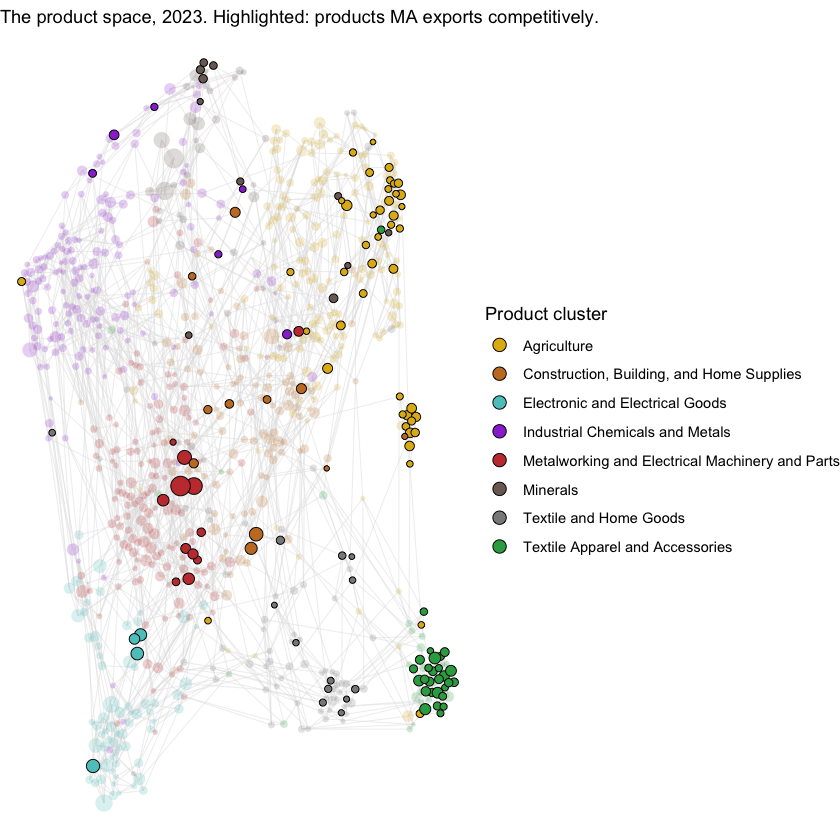

In [10]:
# Atlas product-space cluster palette (Growth Lab design library), matching the
# hex map in the Python source. R needs hex strings, not matplotlib color names.
CLUSTER_COLORS <- c(
  "Agriculture" = "#e0b614",
  "Construction, Building, and Home Supplies" = "#c77c2b",
  "Electronic and Electrical Goods" = "#5cc7c6",
  "Industrial Chemicals and Metals" = "#9c3bd6",
  "Metalworking and Electrical Machinery and Parts" = "#c43d3d",
  "Minerals" = "#7a6a63",
  "Textile and Home Goods" = "#8a8a8a",
  "Textile Apparel and Accessories" = "#2fa84f"
)

# Two point layers on one fill scale so there is a single legend. Products the
# country does not make sit faint (alpha 0.22, thin grey outline); the ones it
# makes sit at full color with a black outline. Node area scales with the square
# root of world trade, as on the Atlas.
ggplot() +
  geom_segment(
    data = edges, aes(x = x, y = y, xend = xend, yend = yend),
    color = "#E3E3E3", linewidth = 0.15
  ) +
  geom_point(
    data = subset(nodes, !in_basket),
    aes(product_space_x, product_space_y, fill = product_space_cluster_name, size = node_size),
    shape = 21, color = "grey70", stroke = 0.1, alpha = 0.22
  ) +
  geom_point(
    data = subset(nodes, in_basket),
    aes(product_space_x, product_space_y, fill = product_space_cluster_name, size = node_size),
    shape = 21, color = "black", stroke = 0.4, alpha = 1
  ) +
  scale_fill_manual(values = CLUSTER_COLORS, name = "Product cluster") +
  scale_size_continuous(range = c(0.6, 5.5), guide = "none") +
  guides(fill = guide_legend(override.aes = list(size = 3.5, alpha = 1))) +
  labs(
    title = paste0(
      "The product space, ", YEAR, ". Highlighted: products ", COUNTRY,
      " exports competitively."
    )
  ) +
  theme_void(base_size = 11) +
  theme(
    plot.background = element_rect(fill = "white", color = NA),
    panel.background = element_rect(fill = "white", color = NA),
    plot.title = element_text(size = 11, hjust = 0)
  )

In [11]:
# Self-check: the join worked and the highlight is the basket.
matched <- mean(nodes$field %in% colnames(mcp))
if (!(matched > 0.95)) stop("only ", round(100 * matched), "% of layout products matched; zero-pad the HS codes.")
expected_hl <- sum(mcp[COUNTRY, intersect(colnames(mcp), nodes$field)] == 1)
if (sum(nodes$in_basket) != expected_hl) stop("highlighted nodes must equal the basket restricted to the layout.")
cat(
  "OK: layout joined (", sprintf("%.0f%%", 100 * matched), "matched) and",
  sum(nodes$in_basket), "products highlighted for", COUNTRY, ".\n"
)

OK: layout joined ( 100% matched) and 129 products highlighted for MA .


## 5. Density

Density is the share of a product's total relatedness that a country already holds. The package weights each product's proximities by the country's M-hat and divides by the product's total proximity, on the same zeroed-diagonal proximity object. That is the one matrix product (m_hat %*% phi) / colSums(phi) opened up. A density of 0.25 means a quarter of everything related to the product is already in the basket, and tomorrow this number becomes the regressor in the entry regressions.

In [12]:
density <- as.matrix(economiccomplexity::density(m_hat, prox$proximity_product))

ma_density <- density[COUNTRY, ]
ma_basket <- mcp[COUNTRY, ] # membership from the binary RCA > 1 basket
in_basket_mean <- mean(ma_density[ma_basket == 1])
out_basket_mean <- mean(ma_density[ma_basket == 0])
cat(
  COUNTRY, "density:", round(in_basket_mean, 3), "inside the RCA > 1 basket,",
  round(out_basket_mean, 3), "outside it\n"
)

# Self-check: density is a share, and relatedness concentrates around the basket,
# so the products the country already makes sit denser than the ones it does not.
# Both means match the Python (0.220 inside, 0.187 outside).
if (min(density) < 0 || max(density) > 1 + 1e-9) stop("density is a share and must lie in [0, 1].")
if (!(in_basket_mean > out_basket_mean)) stop("the basket must sit at higher average density than the rest.")
if (abs(in_basket_mean - 0.220) > 0.03 || abs(out_basket_mean - 0.187) > 0.03) {
  stop(
    "density means should reproduce the Python's 0.220 and 0.187, got ",
    round(in_basket_mean, 3), " and ", round(out_basket_mean, 3), "."
  )
}
cat("OK: density is a bounded share and the basket sits denser than the rest, matching Python.\n")

MA density: 0.22 inside the RCA > 1 basket, 0.187 outside it


OK: density is a bounded share and the basket sits denser than the rest, matching Python.


In [13]:
# One outside check, as on Day 1: WIPO publishes its own relatedness density.
# Every row is the Production dimension (Field IDs start with P), so a Period and
# Unit filter is all we need.
wipo_density <- read_parquet(file.path(PACKET, "exports", "densities.parquet")) %>%
  filter(Period == YEAR, Unit == COUNTRY)
wipo_v <- setNames(wipo_density$`Relatedness Density`, wipo_density$`Field ID`)
common_w <- intersect(names(ma_density), names(wipo_v))
rho_wipo <- cor(ma_density[common_w], wipo_v[common_w], method = "spearman")
cat("Spearman(our density, WIPO density) =", round(rho_wipo, 3), "over", length(common_w), "products\n")

# Self-check: agreement should be real and imperfect. WIPO uses a different
# presence rule AND a different proximity matrix, and density inherits both, so
# the gap is wider than Day 1's PCI comparison.
if (!(rho_wipo > 0.3 && rho_wipo < 0.95)) {
  stop("our density should agree with WIPO's directionally but imperfectly, got ", round(rho_wipo, 3), ".")
}
cat("OK: real but imperfect agreement with WIPO (", round(rho_wipo, 3), "), as expected.\n")

Spearman(our density, WIPO density) = 0.606 over 862 products


OK: real but imperfect agreement with WIPO ( 0.606 ), as expected.


## 6. The shortlist

Cross density with PCI for every product the country does not yet export: density says how reachable it is, PCI says how sophisticated it is. The corner worth attention is high on both. `complexity_outlook()` adds the complexity outlook gain (COG) per product, how much new reach entering it would unlock.

In [14]:
# COG and COI from the package, on the continuous inputs. The R package's outlook
# index (COI) sits on its own scale and does not crosswalk to the Python package's
# COI, so we rank by density and show COG for context rather than comparing the
# scalar index across the two implementations.
outlook <- complexity_outlook(m_hat, phi, pci_con)
cog <- as.matrix(outlook$complexity_outlook_gain)

# Candidates are products the country does not yet export competitively (RCA < 1),
# kept above the median PCI of that candidate set, then ranked by density.
ma_rca <- rca[COUNTRY, ]
candidates <- data.frame(
  field = names(ma_density),
  density = as.numeric(ma_density),
  pci = as.numeric(pci_con[names(ma_density)]),
  rca = as.numeric(ma_rca[names(ma_density)]),
  cog = as.numeric(cog[COUNTRY, names(ma_density)]),
  stringsAsFactors = FALSE
)
candidates <- candidates[candidates$rca < 1 & !is.na(candidates$pci), ]
pci_median <- median(candidates$pci)

opportunities <- candidates[candidates$pci > pci_median, ]
opportunities <- opportunities[order(-opportunities$density), ][1:15, ]
opportunities$product <- prod_name[opportunities$field]
opportunities$world_exports_bnUSD <- round(we_lookup[opportunities$field] / 1e9, 1)
print(
  opportunities[, c("product", "density", "pci", "cog", "world_exports_bnUSD")],
  row.names = FALSE, digits = 3
)

# Self-check: the table is what it claims to be.
if (!all(opportunities$rca < 1)) stop("every opportunity must be a product the country does not yet export (RCA < 1).")
if (!(nrow(opportunities) == 15 && !is.unsorted(rev(opportunities$density)))) {
  stop("the table must hold 15 rows sorted by density, largest first.")
}
if (any(is.na(opportunities$cog))) stop("every row needs its COG from complexity_outlook().")
cat(
  "OK:", nrow(opportunities), "ranked opportunities for", COUNTRY,
  "(top families: Aluminum Structures, Sausages, Other Plastic Sheets and Articles, Transformers).\n"
)

                        product density   pci    cog world_exports_bnUSD
            Aluminum Structures   0.211 0.387 0.0621                14.9
                       Sausages   0.204 0.372 0.0781                 5.5
           Other Plastic Sheets   0.203 0.602 0.0946                24.2
         Other Plastic Articles   0.200 0.441 0.0789               107.1
                   Transformers   0.200 0.527 0.0891               110.6
          Plastic Sanitary Ware   0.199 0.439 0.1065                 4.1
      Monitors and TV Equipment   0.198 0.403 0.1029                55.6
         Retail Pharmaceuticals   0.198 0.464 0.0934               329.8
        Other Aluminum Articles   0.197 0.578 0.1203                17.2
            Narrow Coated Steel   0.197 0.439 0.0989                 4.6
             Cast Iron Articles   0.197 0.444 0.0963                 6.4
  Textile and Leather Finishing   0.195 0.564 0.1266                 3.3
        Refrigeration Equipment   0.194 0.627 0.132

OK: 15 ranked opportunities for MA (top families: Aluminum Structures, Sausages, Other Plastic Sheets and Articles, Transformers).


The model ranks; you judge. Proximity is revealed co-location, not a causal recipe, and everything here rests on trade data alone. Tomorrow's regressions test whether nearby products actually get entered more often, which is the claim behind this table.

## 7. Reconcile with the Python notebook

Every headline number from the Python notebook comes back from the R pipeline. ECI, PCI, proximity, and density all come from `economiccomplexity` on the same M-hat, and the numbers line up.

| Metric | Python | R (`economiccomplexity`) |
|---|---|---|
| Morocco diversity | 129 | 129 |
| Binary ECI (standardized) | -0.47 (rank 123) | -0.468 (rank 123) |
| Continuous ECI (standardized) | -0.06 (rank 111) | -0.062 (rank 111) |
| Spearman(binary ECI, continuous ECI) | 0.965 | 0.965 |
| phi(Women's Knit Shirts, Women's Knit Suits), continuous | 0.538 | 0.538 |
| Toy phi(Wheat, Textiles) / (Motorcycles, Cell phones) | 0.5 / 1.0 | 0.5 / 1.0 |
| Morocco density inside basket / outside | 0.220 / 0.187 | 0.220 / 0.187 |
| Spearman(our density, WIPO density) | 0.606 | 0.606 |
| Top opportunity families | Aluminum Structures, Sausages, Other Plastic Sheets and Articles, Transformers | same |

The one wide gap is against WIPO, near 0.61 rather than 1.0, and it is a difference of method rather than a mistake. Density inherits WIPO's different presence rule and its different proximity matrix at once, so the two gaps compound. The package carries the whole week now, and the one or two lines of matrix algebra behind each call stay in the comments so the density regressor tomorrow is never a black box.